<a href="https://colab.research.google.com/github/niveditha04-yellanuru/AI-Internship-Project/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROJECT TITLE:**
## **Semiconductor Manufacturing Yield Prediction using PCA and Machine Learning**

**STEP 1: IMPORT REQUIRED LIBRARIES**

**Definition**

Importing libraries means loading required Python packages to perform data analysis, preprocessing, visualization, machine learning modeling, and evaluation.

**Working Process**

*   Load numerical and data handling libraries
*   Load visualization libraries
*   Load preprocessing and modeling libraries
*   Load evaluation metrics
*   Suppress unnecessary warnings










In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE
import joblib

# **STEP 2: IMPORT AND EXPLORE DATA**

Definition

Data import is the process of loading the dataset into the environment for analysis.

.Working Process

*   
*   List itemList item



Load dataset using pandas

Check number of rows and columns

View first few records

Check data types

In [3]:
df = pd.read_csv("signal-data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1358, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1.0
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1.0
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1.0
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1.0
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1.0


# **STEP 3: DATA CLEANSING**


📌 Definition

Data cleansing removes noise, handles missing values, and prepares clean data for modeling.

📌 Working Process

Replace missing symbols (?) with NaN

Convert all columns to numeric

Drop columns with more than 50% missing values

Fill remaining missing values using mean

In [8]:
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')

threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)

df = df.fillna(df.mean())

print("After Cleaning Shape:", df.shape)

After Cleaning Shape: (1358, 567)


# **STEP 4: DATA ANALYSIS & VISUALIZATION**


📌 Definition

Exploratory Data Analysis (EDA) helps understand distribution and relationships between variables.

📌 Working Process

Analyze target variable distribution

Identify imbalance

Visualize using count plot

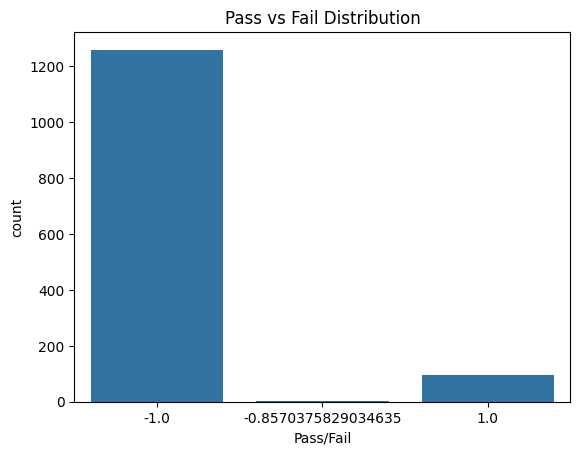

In [5]:
sns.countplot(x=df['Pass/Fail'])
plt.title("Pass vs Fail Distribution")
plt.show()

# **STEP 5: DATA PREPROCESSING**


**5.1 Separate Features and Target**
📌 Definition

Separating independent variables (X) and dependent variable (y).

In [6]:
X = df.drop("Pass/Fail", axis=1)
y = df["Pass/Fail"]

# **5.2 Handle Imbalance using SMOTE**


Definition

SMOTE generates synthetic samples of minority class to balance dataset.

📌 Working Process

Identify minority class

Generate synthetic data points

Equalize class distribution

In [13]:
y = y.round().astype(int)
y = y.replace({-1: 0, 1: 1})
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Balanced Classes:", np.bincount(y_res))

Balanced Classes: [1261 1261]


# **5.3 Standardization**


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# PCA
pca = PCA(n_components=0.95) # Retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

print("Original Features (after SMOTE):", X_res.shape[1])
print("Reduced Features (after PCA):", X_pca.shape[1])

# Train-Test Split
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y_res, test_size=0.3, random_state=42)


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter tuning
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train_pca, y_train)

rf_best = grid_rf.best_estimator_

# Cross validation
cv_score_rf = cross_val_score(rf_best, X_train_pca, y_train, cv=5)

# Evaluation
rf_pred = rf_best.predict(X_test_pca)

print("Best Parameters:", grid_rf.best_params_)
print("Cross Validation Accuracy:", cv_score_rf.mean())
print("Test Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Original Features (after SMOTE): 566
Reduced Features (after PCA): 150
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Cross Validation Accuracy: 0.9903682719546743
Test Accuracy: 0.9867899603698811
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       370
           1       0.99      0.98      0.99       387

    accuracy                           0.99       757
   macro avg       0.99      0.99      0.99       757
weighted avg       0.99      0.99      0.99       757



In [15]:
from sklearn.svm import SVC

svm = SVC()

param_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

grid_svm = GridSearchCV(svm, param_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train_pca, y_train)

svm_best = grid_svm.best_estimator_

cv_score_svm = cross_val_score(svm_best, X_train_pca, y_train, cv=5)

svm_pred = svm_best.predict(X_test_pca)

print("Best Parameters:", grid_svm.best_params_)
print("Cross Validation Accuracy:", cv_score_svm.mean())
print("Test Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Cross Validation Accuracy: 0.9892351274787536
Test Accuracy: 0.9933949801849405
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       370
           1       0.99      1.00      0.99       387

    accuracy                           0.99       757
   macro avg       0.99      0.99      0.99       757
weighted avg       0.99      0.99      0.99       757



In [16]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

# Train model
nb.fit(X_train_pca, y_train)

# Cross validation
cv_score_nb = cross_val_score(nb, X_train_pca, y_train, cv=5)

# Prediction
nb_pred = nb.predict(X_test_pca)

print("Cross Validation Accuracy:", cv_score_nb.mean())
print("Test Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Cross Validation Accuracy: 0.9620396600566572
Test Accuracy: 0.9498018494055482
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       370
           1       0.98      0.92      0.95       387

    accuracy                           0.95       757
   macro avg       0.95      0.95      0.95       757
weighted avg       0.95      0.95      0.95       757



In [17]:
models = {
    "Random Forest": rf_best,
    "SVM": svm_best,
    "Naive Bayes": nb
}

for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_pca))
    test_acc = accuracy_score(y_test, model.predict(X_test_pca))
    print(f"{name} -> Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

Random Forest -> Train Accuracy: 1.0000, Test Accuracy: 0.9868
SVM -> Train Accuracy: 1.0000, Test Accuracy: 0.9934
Naive Bayes -> Train Accuracy: 0.9632, Test Accuracy: 0.9498
